## Laboratuvar: Transpose Konvolüsyonun Pratik Uygulaması  

**Tahmini süre: 30 dakika**

Bu laboratuvar, görüntü yeniden yapılandırma gibi görevler için transpose konvolüsyon katmanları kullanan modellerin oluşturulması, eğitilmesi ve değerlendirilmesi süreçlerinde size rehberlik edecektir. 

##### Öğrenim hedefleri: 

Bu laboratuvarın sonunda şunları yapabileceksiniz: 

- Keras kullanarak pratik senaryolarda transpoz konvolüsyonu uygulayabileceksiniz.  

- Modeli oluşturabilecek, derleyebilecek, eğitebilecek ve değerlendirebileceksiniz 

- Sonuçları görselleştirebileceksiniz  

##### Ön koşullar: 

- Python programlama konusunda temel bilgi 

- Konvolüsyonel sinir ağı (CNN) kavramlarına aşinalık 

- Keras ve TensorFlow'un yüklü olması 




Translated with DeepL.com (free version)

#### Adımlar: 
**1. Adım: Gerekli Kütüphaneleri İçe Aktarın**

Başlamadan önce, gerekli kütüphaneleri içe aktardığınızdan emin olun: TensorFlow ve Keras. Keras, TensorFlow içinde `tensorflow.keras` olarak bulunur. 


In [1]:
import warnings
warnings.simplefilter('ignore')

!pip install tensorflow==2.16.2 

!pip install matplotlib 
import tensorflow as tf 

from tensorflow.keras.models import Model 

from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, UpSampling2D 

import numpy as np 

import matplotlib.pyplot as plt 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.8/590.8 MB 8.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 26.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 9.8 MB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 853.3 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 30.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 21.3 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 5.8 MB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 22.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 18.8 MB/s eta 0:00:00
   ━━━━━

2026-03-27 13:13:43.661416: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-27 13:13:43.662728: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-27 13:13:43.669061: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-27 13:13:43.685197: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-27 13:13:43.716469: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registe

**Açıklama:**

 `tensorflow`, Python'da makine öğrenimi için kullanılan ana kütüphanedir. 

  `Model, Input, Conv2D ve Conv2DTranspose`, modelinizdeki katmanları oluşturmak ve işlemek için kullanılır. 

  `numpy` ve `matplotlib`, veri işleme ve görselleştirme için kullanılır. 

 
**Adım 2: Giriş Katmanını Tanımlayın**

Modeliniz için giriş şeklini tanımlamanız gerekir. Basitlik açısından, 1 kanallı (gri tonlamalı) 28x28 boyutunda bir giriş görüntüsüyle çalıştığınızı varsayalım. 

 


In [2]:
input_layer = Input(shape=(28, 28, 1))

**Açıklama:**

`Input(shape=(28, 28, 1))`, 28x28 boyutlarında gri tonlamalı görüntüler bekleyen bir giriş katmanı oluşturur.


**3. Adım: Evrişimli ve transpoze evrişimli katmanlar ekleyin**

Özellikleri çıkarmak için bir evrişimli katman ekleyeceksiniz; ardından görüntüyü yeniden oluşturmak için bir transpoze evrişimli katman ekleyeceksiniz. 


In [3]:
conv_layer = Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same')(input_layer) 

transpose_conv_layer = Conv2DTranspose(filters=1, kernel_size=(3, 3), activation='sigmoid', padding='same')(conv_layer) 


**Açıklama:**

`Conv2D(filters=32, kernel_size=(3, 3), activation=‘relu’, padding=‘same’)`, 32 filtreye sahip bir konvolüsyon katmanı oluşturur. 

`Conv2DTranspose(filters=1, kernel_size=(3, 3), activation=‘sigmoid’, padding=‘same’)`, görüntüyü yeniden oluşturmak için bir transpoze konvolüsyon katmanı oluşturur. 

**Adım 4: Modeli Oluşturun**

Şimdi, giriş ve çıkış katmanlarını belirleyerek modeli oluşturacaksınız. Özellikleri çıkarmak için bir konvolüsyon katmanı ekleyeceksiniz, ardından görüntüyü yeniden oluşturmak için bir transpoze konvolüsyon katmanı ekleyeceksiniz.


In [4]:
model = Model(inputs=input_layer, outputs=transpose_conv_layer)

**Açıklama:**

`Model(inputs=input_layer, outputs=transpose_conv_layer)`, konvolüsyonel ve transpoze konvolüsyonel katmanlar aracılığıyla giriş katmanını çıkış katmanına bağlayan bir Keras modeli oluşturur.  

**Adım 5: Modeli Derleyin**

Modeli eğitmeden önce derlemeniz gerekir. Kayıp fonksiyonunu, optimizeri ve değerlendirme metriklerini belirleyeceksiniz. 


In [5]:
model.compile(optimizer='adam', loss='mean_squared_error')

**Açıklama:**

- optimizer=`adam`, Adam optimizörünü belirtir. 

- loss=`mean_squared_error`, ortalama karesel hata kayıp fonksiyonunu belirtir.  


**6. Adım: Modeli Eğitme**

Artık modeli bazı eğitim verileriyle eğitebilirsiniz. Bu örnekte, X_train'in eğitim girdi verilerimiz olduğunu varsayalım.


In [6]:
# Generate synthetic training data 

X_train = np.random.rand(1000, 28, 28, 1) 

y_train = X_train # For reconstruction, the target is the input 

history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2) 

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0748 - val_loss: 0.0637
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0529 - val_loss: 0.0411
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0321 - val_loss: 0.0233
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0175 - val_loss: 0.0119
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0088 - val_loss: 0.0063
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0051 - val_loss: 0.0040
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0035 - val_loss: 0.0030
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0027 - val_loss: 0.0024
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0023 - val_loss: 0.0021
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0020 - val_loss: 0.0019


**Açıklama:**

- X_train, gerçek eğitim verilerinizin yerine geçen bir yer tutucudur. 

- y_train, görüntü yeniden yapılandırması için X_train ile aynıdır. 

- model.fit, modeli belirtilen epoch sayısı ve parti boyutu için eğitir.

  
**7. Adım: Modeli Değerlendirme**

Eğitimden sonra, modeli test verileri üzerinde değerlendirerek performansını görebilirsiniz. 


In [7]:
 # Generate synthetic test data 

X_test = np.random.rand(200, 28, 28, 1) 

y_test = X_test 

loss = model.evaluate(X_test, y_test) 

print(f'Test loss: {loss}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0019
Test loss: 0.0018936751876026392


**Açıklama:**

`X_test` ve `y_test`, gerçek test verilerinizin yerine geçen yer tutuculardır. 

`model.evaluate`, test verileri üzerinde modelin kayıp değerini hesaplar. 

**8. Adım: Sonuçları Görselleştirme**

Modelin performansını daha iyi anlamak için, yeniden oluşturulan bazı görüntüleri görselleştirelim.  


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


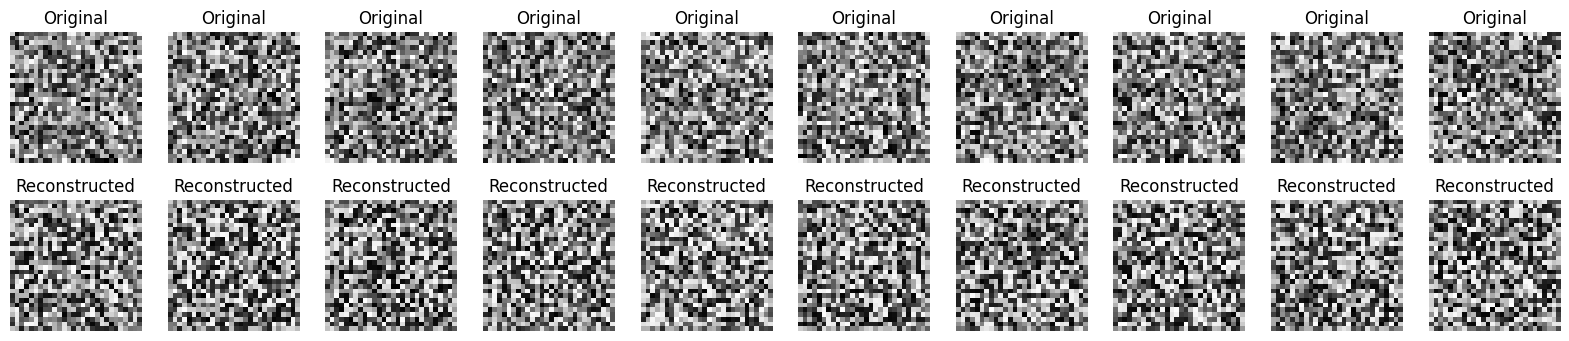

In [8]:
# Predict on test data 
y_pred = model.predict(X_test) 

# Plot some sample images 

n = 10 # Number of samples to display 

plt.figure(figsize=(20, 4))

for i in range(n): 

    # Display original 
    ax = plt.subplot(2, n, i + 1) 
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original") 
    plt.axis('off') 
    # Display reconstruction 
    ax = plt.subplot(2, n, i + 1 + n) 
    plt.imshow(y_pred[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show() 

**Açıklama:**

`model.predict`, test verileri için tahminler üretir. 

`plt.imshow`, karşılaştırma amacıyla orijinal ve yeniden oluşturulan görüntüleri yan yana gösterir. 


### Practice exercises


#### Alıştırma 1: Farklı Çekirdek Boyutlarıyla Deney Yapın 

**Amaç:** Farklı çekirdek boyutlarının modelin performansı üzerindeki etkisini anlamak. 

**Talimatlar:**
1. `Conv2D` ve `Conv2DTranspose` katmanlarının çekirdek boyutunu değiştirin. 
2. Modeli yeniden derleyin, eğitin ve değerlendirin. 
3. Performans farklılıklarını gözlemleyin ve kaydedin.


In [9]:
from tensorflow.keras.layers import Dropout, Conv2D, Conv2DTranspose, Input
from tensorflow.keras.models import Model

# Define the input layer
input_layer = Input(shape=(28, 28, 1))

# Add convolutional and transpose convolutional layers with different kernel sizes
conv_layer = Conv2D(filters=32, kernel_size=(5, 5), activation='relu', padding='same')(input_layer)
transpose_conv_layer = Conv2DTranspose(filters=1, kernel_size=(5, 5), activation='sigmoid', padding='same')(conv_layer)

# Create the model
model = Model(inputs=input_layer, outputs=transpose_conv_layer)

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
loss = model.evaluate(X_test, y_test)
print(f'Test loss: {loss}')

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0663 - val_loss: 0.0451
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0300 - val_loss: 0.0168
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0109 - val_loss: 0.0066
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0051 - val_loss: 0.0040
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0035 - val_loss: 0.0032
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0030 - val_loss: 0.0028
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0027 - val_loss: 0.0025
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0024 - val_loss: 0.0024
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0023 - val_loss: 0.0022
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0022 - val_loss: 0.0021
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0021
Test loss: 0.0020924655254930258


<details>
<summary>Click here for solution</summary> </br>

```python
from tensorflow.keras.layers import Dropout, Conv2D, Conv2DTranspose, Input
from tensorflow.keras.models import Model

# Define the input layer
input_layer = Input(shape=(28, 28, 1))

# Add convolutional and transpose convolutional layers with different kernel sizes
conv_layer = Conv2D(filters=32, kernel_size=(5, 5), activation='relu', padding='same')(input_layer)
transpose_conv_layer = Conv2DTranspose(filters=1, kernel_size=(5, 5), activation='sigmoid', padding='same')(conv_layer)

# Create the model
model = Model(inputs=input_layer, outputs=transpose_conv_layer)

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
loss = model.evaluate(X_test, y_test)
print(f'Test loss: {loss}')


#### Alıştırma 2: Dropout Katmanları Ekleme

**Amaç:** Aşırı uyumlanmayı önlemek için dropout katmanları ekleyin.

**Talimatlar:**
1. Evrişimli katmanın arkasına dropout katmanları ekleyin. 
2. Dropout oranını 0,5 olarak ayarlayın.
3. Modeli yeniden derleyin, eğitin ve değerlendirin.


In [10]:
from tensorflow.keras.layers import Dropout, Conv2D, Conv2DTranspose, Input
from tensorflow.keras.models import Model

# Define the input layer
input_layer = Input(shape=(28, 28, 1))

# Add convolutional, dropout, and transpose convolutional layers
conv_layer = Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same')(input_layer)
dropout_layer = Dropout(0.5)(conv_layer)
transpose_conv_layer = Conv2DTranspose(filters=1, kernel_size=(3, 3), activation='sigmoid', padding='same')(dropout_layer)

# Create the model
model = Model(inputs=input_layer, outputs=transpose_conv_layer)

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
loss = model.evaluate(X_test, y_test)
print(f'Test loss: {loss}')

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0747 - val_loss: 0.0623
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0539 - val_loss: 0.0405
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0355 - val_loss: 0.0231
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0227 - val_loss: 0.0127
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0159 - val_loss: 0.0081
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0127 - val_loss: 0.0060
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0109 - val_loss: 0.0048
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0099 - val_loss: 0.0041
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0091 - val_loss: 0.0036
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0086 - val_loss: 0.0032
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0032
Test loss: 0.0032089788001030684


<details>
<summary>Click here for solution</summary> </br>

```python
from tensorflow.keras.layers import Dropout, Conv2D, Conv2DTranspose, Input
from tensorflow.keras.models import Model

# Define the input layer
input_layer = Input(shape=(28, 28, 1))

# Add convolutional, dropout, and transpose convolutional layers
conv_layer = Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same')(input_layer)
dropout_layer = Dropout(0.5)(conv_layer)
transpose_conv_layer = Conv2DTranspose(filters=1, kernel_size=(3, 3), activation='sigmoid', padding='same')(dropout_layer)

# Create the model
model = Model(inputs=input_layer, outputs=transpose_conv_layer)

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
loss = model.evaluate(X_test, y_test)
print(f'Test loss: {loss}')


#### Alıştırma 3: Farklı Aktivasyon Fonksiyonlarını Kullanma 

**Amaç:** Farklı aktivasyon fonksiyonlarını denemek ve bunların model performansı üzerindeki etkisini gözlemlemek. 

**Talimatlar:**
1. Evrişimli ve transpoze evrişimli katmanların aktivasyon fonksiyonunu `tanh` olarak değiştirin. 
2. Modeli yeniden derleyin, eğitin ve değerlendirin.


In [11]:
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, Input
from tensorflow.keras.models import Model

# Define the input layer
input_layer = Input(shape=(28, 28, 1))

# Add convolutional and transpose convolutional layers with different activation functions
conv_layer = Conv2D(filters=32, kernel_size=(3, 3), activation='tanh', padding='same')(input_layer)
transpose_conv_layer = Conv2DTranspose(filters=1, kernel_size=(3, 3), activation='tanh', padding='same')(conv_layer)

# Create the model
model = Model(inputs=input_layer, outputs=transpose_conv_layer)

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
loss = model.evaluate(X_test, y_test)
print(f'Test loss: {loss}')

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.2200 - val_loss: 0.0870
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0650 - val_loss: 0.0449
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0354 - val_loss: 0.0260
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0205 - val_loss: 0.0156
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0129 - val_loss: 0.0105
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0091 - val_loss: 0.0080
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0073 - val_loss: 0.0067
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0063 - val_loss: 0.0059
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0057 - val_loss: 0.0054
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0053 - val_loss: 0.0051
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0051
Test loss: 0.005144638475030661


<details>
<summary>Click here for solution</summary> </br>

```python

from tensorflow.keras.layers import Conv2D, Conv2DTranspose, Input
from tensorflow.keras.models import Model

# Define the input layer
input_layer = Input(shape=(28, 28, 1))

# Add convolutional and transpose convolutional layers with different activation functions
conv_layer = Conv2D(filters=32, kernel_size=(3, 3), activation='tanh', padding='same')(input_layer)
transpose_conv_layer = Conv2DTranspose(filters=1, kernel_size=(3, 3), activation='tanh', padding='same')(conv_layer)

# Create the model
model = Model(inputs=input_layer, outputs=transpose_conv_layer)

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
loss = model.evaluate(X_test, y_test)
print(f'Test loss: {loss}')

